# EDA on Processed Training Dataset

This notebook performs exploratory data analysis (EDA) on the training dataset located in the processed directory. We will analyze the dataset structure, check for missing values, visualize distributions, and explore correlations.

In [ ]:
# 1. Load Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

In [29]:
# 2. Load Training Dataset (.npy files)
from pathlib import Path
train_manifest = Path('../datasets/processed/manifests/train_manifest.txt')
image_dir = Path('../datasets/processed/images')
images = []
labels = []
with open(train_manifest, 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        # Use only the relative path after the first directory (remove leading 'images/')
        rel_img_path = Path(parts[0])
        if rel_img_path.parts[0] == 'images':
            rel_img_path = Path(*rel_img_path.parts[1:])
        img_path = image_dir / rel_img_path
        label = int(parts[1])
        if img_path.exists():
            img = np.load(img_path)
            images.append(img)
            labels.append(label)
images = np.array(images)
labels = np.array(labels)

In [30]:
# 3. Display Dataset Shape and Basic Info
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
unique_labels, counts = np.unique(labels, return_counts=True)
print(f"Class distribution: {dict(zip(unique_labels, counts))}")

Images shape: (545, 224, 224, 3)
Labels shape: (545,)
Class distribution: {np.int64(0): np.int64(305), np.int64(1): np.int64(147), np.int64(2): np.int64(93)}


Total missing values in images: 0


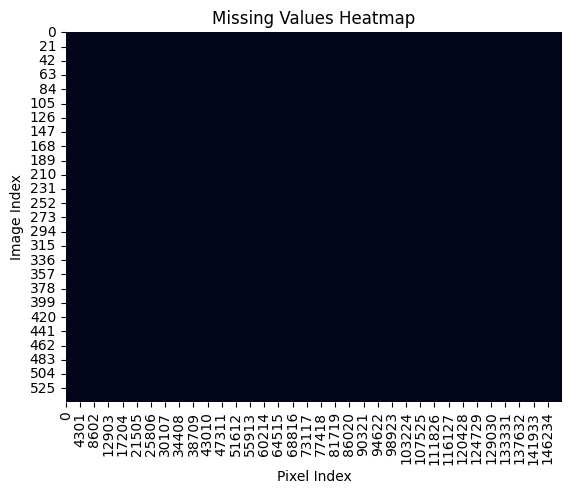

In [31]:
# 4. Check for Missing Values (in images array)
missing = np.isnan(images).sum()
print(f"Total missing values in images: {missing}")
if images.size > 0:
    sns.heatmap(np.isnan(images).reshape(images.shape[0], -1), cbar=False)
else:
    print("No images loaded, cannot display heatmap.")
plt.title('Missing Values Heatmap')
plt.xlabel('Pixel Index')
plt.ylabel('Image Index')
plt.show()

In [32]:
# 5. Statistical Summary of Features
# Flatten images for statistics
if images.size > 0:
    flat_images = images.reshape(images.shape[0], -1)
    df = pd.DataFrame(flat_images)
    print(df.describe())
else:
    flat_images = np.empty((0, 0))
    print("No images loaded, cannot compute statistical summary.")

           0           1           2           3           4           5       \
count  545.000000  545.000000  545.000000  545.000000  545.000000  545.000000   
mean     0.322936    0.322936    0.322936    0.422018    0.422018    0.422018   
std      0.523638    0.523638    0.523638    0.540520    0.540520    0.540520   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
max      2.000000    2.000000    2.000000    2.000000    2.000000    2.000000   

           6           7           8           9       ...      150518  \
count  545.000000  545.000000  545.000000  545.000000  ...  545.000000   
mean     0.420183    0.420183    0.420183    0.403670  ...    0.166972   
std      0.557004    0.557004    0.557004    0.5

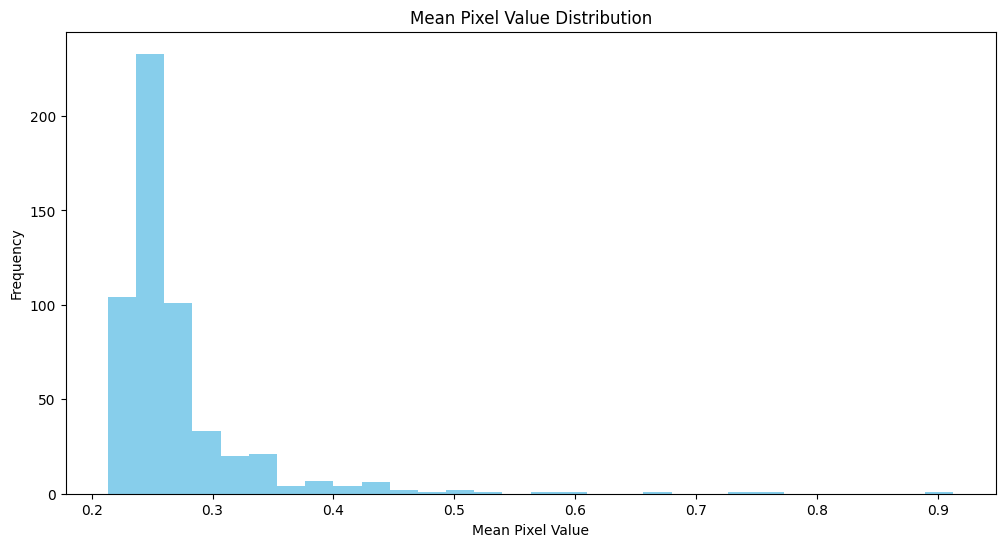

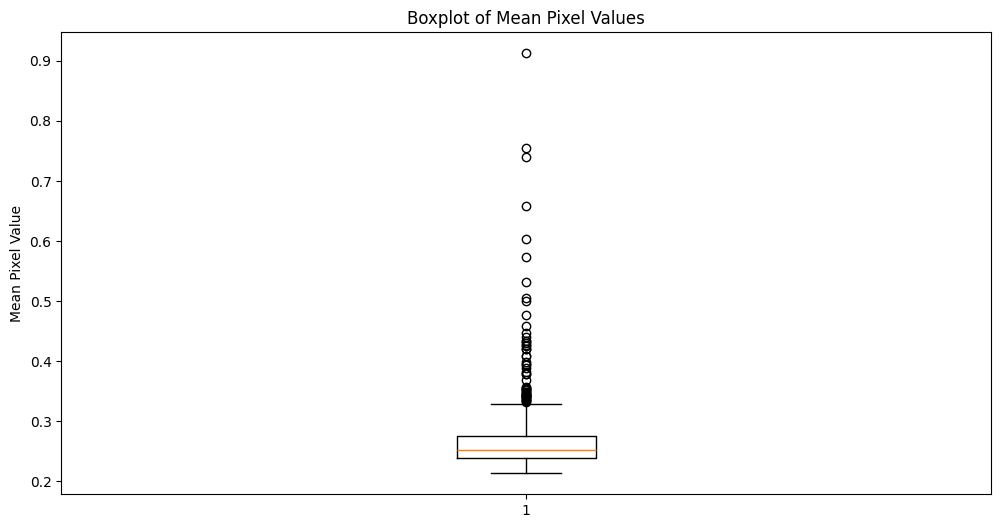

: 

In [ ]:
# 6. Visualize Feature Distributions
plt.figure(figsize=(12, 6))
plt.hist(flat_images.mean(axis=1), bins=30, color='skyblue')
plt.title('Mean Pixel Value Distribution')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(12, 6))
plt.boxplot(flat_images.mean(axis=1))
plt.title('Boxplot of Mean Pixel Values')
plt.ylabel('Mean Pixel Value')
plt.show()

In [ ]:
# 7. Correlation Analysis
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Pixel Features')
plt.show()

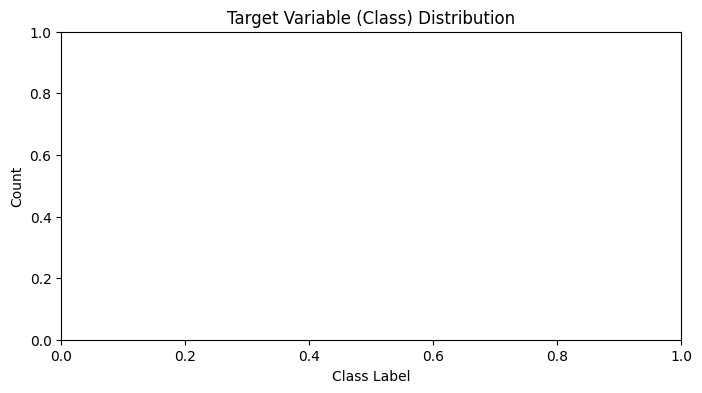

In [ ]:
# 8. Visualize Target Variable Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=labels)
plt.title('Target Variable (Class) Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

In [ ]:
# 9. Visualize Sample Images from Each Class
import random
class_names = {0: 'benign', 1: 'malignant', 2: 'normal'}
plt.figure(figsize=(12, 6))
for class_id in sorted(class_names.keys()):
    idxs = np.where(labels == class_id)[0]
    if len(idxs) == 0:
        print(f'No images found for class {class_names[class_id]}')
        continue
    sample_idxs = random.sample(list(idxs), min(2, len(idxs)))
    for i, idx in enumerate(sample_idxs):
        plt.subplot(3, 2, class_id * 2 + i + 1)
        img = images[idx]
        if img.ndim == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(img)
        plt.title(f'{class_names[class_id]} (idx={idx})')
        plt.axis('off')
plt.tight_layout()
plt.show()

No images found for class benign
No images found for class malignant
No images found for class normal


<Figure size 1200x600 with 0 Axes>

In [ ]:
# 10. Convert at least one .npy image to JPG and visualize
from PIL import Image
import io
import matplotlib.image as mpimg
if images.size > 0:
    # Select the first image
    img = images[0]
    # Normalize if needed (0-255 for uint8 JPG)
    if img.dtype != np.uint8:
        img_to_save = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
    else:
        img_to_save = img
    # Convert grayscale to RGB if needed
    if img_to_save.ndim == 2:
        img_to_save = np.stack([img_to_save]*3, axis=-1)
    pil_img = Image.fromarray(img_to_save)
    # Save to a buffer as JPG
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    buf.seek(0)
    # Read back as an image for visualization
    jpg_img = mpimg.imread(buf, format='jpg')
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray' if img.ndim==2 else None)
    plt.title('Original .npy Image')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(jpg_img)
    plt.title('Converted JPG Image')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No images available to convert.')

No images available to convert.
